# 判定の基準を、結果より先に決める

## Titanic: four pre-registered comparisons | JP / EN

Titanicの解説Notebookは、特徴量を足してスコアが上がれば採用、という形が多くあります。
しかし「上がった」と言えるのは、いくつ上がったときでしょうか。基準を後から決めれば、
出た結果に合わせて基準の方が動きます。

このNotebookでは、**採否の基準を結果を見る前に決めてから**、4つの比較を実行します。
`Cabin` の表現、家族による情報の漏れ、`Age` の欠損処理、木の深さです。

結論を先に書きます。**4つとも「現行のまま」になりました。** 変更に足る根拠が
1つも見つからなかった、というのが結果です。提出スコアも既存と同じ `0.77990` でした。

それでも記録する価値があるのは、途中で次のことが観測できたためです。

- 判定ルールの形を変えると、同じデータで結論が逆転した
- 継続を決めた根拠の数値が、独立な観測で半分以下になった
- 25分割では区別できなかった差が、100分割で順位ごと入れ替わった

### English abstract

Most Titanic notebooks adopt a change when the score goes up. This one fixes the adoption
criterion before looking at any result, then runs four comparisons: how `Cabin` is encoded,
how much family overlap inflates cross-validation, how missing `Age` is filled, and tree depth.

All four ended with no change, and the submission scores exactly what the existing baseline
scored. The record is kept for what appeared on the way: the shape of the decision rule flipped
one conclusion, the estimate that justified continuing halved on independent seeds, and a
ranking reversed once the resolution of the design improved.

## 1. 固定する条件 / Fixed conditions

比較の前に固定するものを置きます。ここを動かしながら結果を読むと、何が効いたのか
切り分けられません。

| 項目 | 固定内容 |
|---|---|
| データ | `train.csv` 891行のみ。`test.csv` は提出まで使わない |
| モデル族 | 決定木。分割条件を列挙して読めるため |
| 指標 | accuracy（4節で理由を述べます） |
| 検証 | 層化5-fold。全ての腕が同一のfoldを使う |
| 乱数 | 木の `random_state` は42で固定 |

そのうえで、比較ごとに**変える条件を1つだけ**決めます。

### 事前登録という手続き / Pre-registration

各比較の前に、次を書いてから実行します。

1. 何と何を比べるか（腕の一覧。実行後に増やさない）
2. どの数字を見るか（主指標を1つ）
3. 何をもって採用とするか（判定式）
4. その設計で**測れる下限**はいくつか

4番目が抜けると、判定できない精度の設計で走らせることになります。実際に一度失敗したので、
その過程も残しました。

> **English:** Before each comparison we fix the arms, the single primary metric, the adoption
> rule, and the resolution the design can actually achieve. The fourth item is the one we forgot
> once, and that failure is kept in the notebook.

## 2. 入力とスキーマの検査 / Input contract

Kaggleでは `/kaggle/input` を探索し、`Survived` を含むtrainと含まないtestの組を選びます。
フォルダ名を決め打ちにすると、入力の付け替えで壊れます。

図中の文字は英語です。Kaggle実行環境に日本語フォントが無く、日本語ラベルは
文字化けするためです。説明は本文側に日本語で置きます。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, export_text

TARGET_COLUMN = "Survived"
ID_COLUMN = "PassengerId"
Z_95 = 1.959963984540054
N_SPLITS = 5
TREE_RANDOM_STATE = 42
N_BOOTSTRAP = 4000

COLORS = {
    "blue": "#2F6690",
    "gold": "#D4A72C",
    "orange": "#D97706",
    "ink": "#263238",
    "muted": "#6B7A82",
    "light": "#D9E1E5",
    "paper": "#FAFBFC",
}
plt.rcParams.update({
    "figure.facecolor": COLORS["paper"],
    "axes.facecolor": COLORS["paper"],
    "axes.edgecolor": COLORS["muted"],
    "axes.labelcolor": COLORS["ink"],
    "text.color": COLORS["ink"],
    "xtick.color": COLORS["ink"],
    "ytick.color": COLORS["ink"],
    "axes.grid": True,
    "grid.color": COLORS["light"],
    "axes.unicode_minus": False,
    "font.size": 10,
})

print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

pandas: 3.0.5
scikit-learn: 1.9.0


In [2]:
def is_titanic_pair(directory: Path) -> bool:
    train_path = directory / "train.csv"
    test_path = directory / "test.csv"
    if not train_path.exists() or not test_path.exists():
        return False
    train_columns = pd.read_csv(train_path, nrows=2).columns
    test_columns = pd.read_csv(test_path, nrows=2).columns
    return (
        TARGET_COLUMN in train_columns
        and TARGET_COLUMN not in test_columns
        and ID_COLUMN in train_columns
        and ID_COLUMN in test_columns
    )


KAGGLE_INPUT_ROOT = Path("/kaggle/input")
LOCAL_CANDIDATES = [Path("data"), Path("../data")]

if KAGGLE_INPUT_ROOT.exists():
    kaggle_candidates = sorted({
        path.parent
        for path in KAGGLE_INPUT_ROOT.rglob("train.csv")
        if is_titanic_pair(path.parent)
    })
else:
    kaggle_candidates = []

if len(kaggle_candidates) == 1:
    DATA_DIR = kaggle_candidates[0]
    OUTPUT_DIR = Path("/kaggle/working")
    ENVIRONMENT = "Kaggle"
elif len(kaggle_candidates) > 1:
    raise RuntimeError(
        f"Multiple Titanic train/test pairs were found: {kaggle_candidates}"
    )
else:
    matching_local = [path for path in LOCAL_CANDIDATES if is_titanic_pair(path)]
    if len(matching_local) != 1:
        raise FileNotFoundError(
            "Attach the Titanic competition data on Kaggle, or place "
            "train.csv and test.csv under the local data directory."
        )
    DATA_DIR = matching_local[0]
    OUTPUT_DIR = Path("preregistration_publish/outputs")
    ENVIRONMENT = "Local"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

IS_OFFICIAL_SHAPE = train.shape == (891, 12) and test.shape == (418, 11)

assert TARGET_COLUMN in train.columns and TARGET_COLUMN not in test.columns
assert train[ID_COLUMN].is_unique and test[ID_COLUMN].is_unique
assert set(train[TARGET_COLUMN].unique()).issubset({0, 1})
assert set(train.columns) - {TARGET_COLUMN} == set(test.columns)

y = train[TARGET_COLUMN]
survivors = int(y.sum())

display(Markdown(
    f"**Environment:** `{ENVIRONMENT}`  \n"
    f"**Input:** `{DATA_DIR}`  \n"
    f"**Data check:** "
    f"`{'official Titanic competition data' if IS_OFFICIAL_SHAPE else 'non-official shape'}`  \n"
    f"**Shapes:** train `{train.shape}`, test `{test.shape}`  \n"
    f"**Target:** {survivors} survived / {len(train) - survivors} died "
    f"({survivors / len(train):.4f})"
))

**Environment:** `Local`  
**Input:** `data`  
**Data check:** `official Titanic competition data`  
**Shapes:** train `(891, 12)`, test `(418, 11)`  
**Target:** 342 survived / 549 died (0.3838)

## 3. 比率には分母と幅がある / Every rate carries a denominator

生存率は割り算の結果である前に、限られた人数からの推定値です。ここでWilson信頼区間を
使います。比率が0や1に寄る場合や分母が小さい場合に、正規近似より妥当な範囲に収まるためです。

区間の意味は「同じ手続きを繰り返したとき、95%の区間が真の比率を含む」であり、
「真の比率が95%の確率でこの中にある」ではありません。

実行前の予想を1つ置きます。**層に分けると分母が減るので、区間は広がるはずです。**
これを実測と突き合わせます。

> **English:** A rate is an estimate from a limited denominator. The prediction to test is that
> splitting into layers shrinks the denominator and therefore widens the interval.

In [3]:
def wilson_interval(successes: int, total: int, z: float = Z_95) -> tuple[float, float]:
    if total == 0:
        return (np.nan, np.nan)
    proportion = successes / total
    denominator = 1.0 + z**2 / total
    center = (proportion + z**2 / (2 * total)) / denominator
    half_width = (
        z * np.sqrt(proportion * (1 - proportion) / total + z**2 / (4 * total**2))
        / denominator
    )
    return center - half_width, center + half_width


def error_bar_widths(estimate, lower, upper) -> list[np.ndarray]:
    # p=0 や p=1 では区間の端と推定値が浮動小数点誤差の分だけ逆転しうる
    below = np.maximum(np.asarray(estimate) - np.asarray(lower), 0.0)
    above = np.maximum(np.asarray(upper) - np.asarray(estimate), 0.0)
    return [below, above]


def rate_row(label: str, frame: pd.DataFrame) -> dict:
    successes = int(frame[TARGET_COLUMN].sum())
    total = len(frame)
    low, high = wilson_interval(successes, total)
    return {
        "group": label,
        "n": total,
        "rate": successes / total,
        "ci_low": low,
        "ci_high": high,
        "width": high - low,
    }


rows = [rate_row("all passengers", train)]
for column in ["Sex", "Pclass"]:
    for value, part in train.groupby(column):
        rows.append(rate_row(f"{column}={value}", part))
for (pclass, sex), part in train.groupby(["Pclass", "Sex"]):
    rows.append(rate_row(f"Pclass={pclass}, {sex}", part))

rate_table = pd.DataFrame(rows)
display(rate_table.round(4))

,group,n,rate,ci_low,ci_high,width
0,all passengers,891,0.3838,0.3525,0.4162,0.0637
1,Sex=female,314,0.7420,0.6909,0.7873,0.0964
2,Sex=male,577,0.1889,0.1591,0.2229,0.0638
3,Pclass=1,216,0.6296,0.5635,0.6912,0.1277
4,Pclass=2,184,0.4728,0.4020,0.5448,0.1428
5,Pclass=3,491,0.2424,0.2066,0.2822,0.0756
6,"Pclass=1, female",94,0.9681,0.9103,0.9891,0.0788
7,"Pclass=1, male",122,0.3689,0.2885,0.4573,0.1688
8,"Pclass=2, female",76,0.9211,0.8383,0.9633,0.1250
9,"Pclass=2, male",108,0.1574,0.1007,0.2377,0.1370


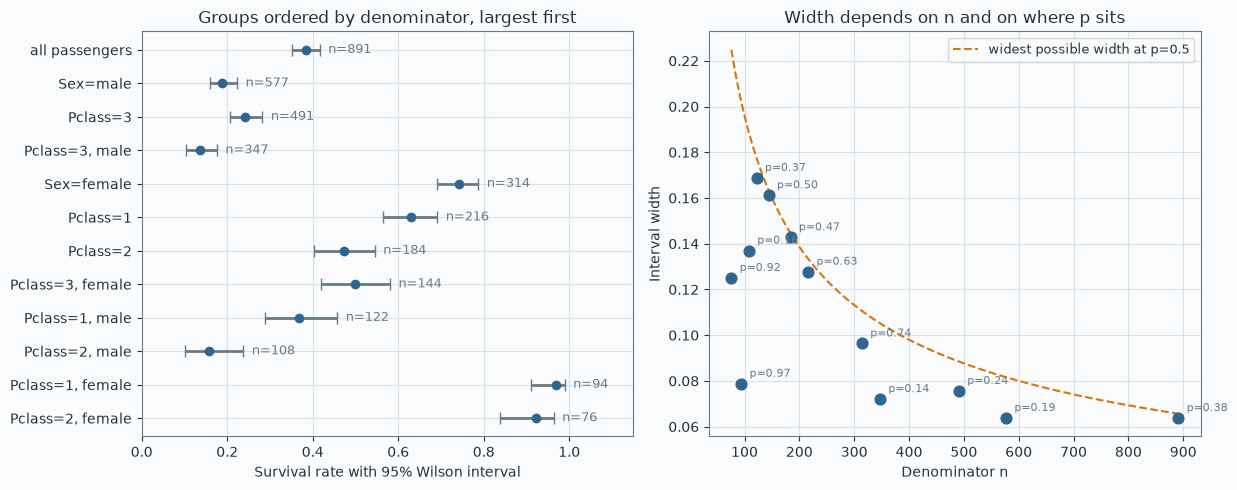

- 最も狭い区間は `all passengers`（n=891, p=0.38）の `0.064`、最も広いのは `Pclass=1, male`（n=122, p=0.37）の `0.169`。  
- `Pclass=2`（n=184）より分母が小さいのに区間が狭い群が `3` 個あった。予想した「分母が減れば広がる」は、単調には成り立たなかった。

In [4]:
ordered = rate_table.sort_values("n", ascending=False).reset_index(drop=True)
positions = np.arange(len(ordered))

figure, axes = plt.subplots(1, 2, figsize=(12.5, 5.0))

axes[0].errorbar(
    ordered["rate"],
    positions,
    xerr=error_bar_widths(ordered["rate"], ordered["ci_low"], ordered["ci_high"]),
    fmt="o",
    color=COLORS["blue"],
    ecolor=COLORS["muted"],
    elinewidth=2,
    capsize=4,
)
for position, row in zip(positions, ordered.itertuples()):
    axes[0].text(
        row.ci_high + 0.02, position, f"n={row.n}",
        va="center", fontsize=9, color=COLORS["muted"],
    )
axes[0].set_yticks(positions)
axes[0].set_yticklabels(ordered["group"])
axes[0].invert_yaxis()
axes[0].set_xlim(0, 1.15)
axes[0].set_xlabel("Survival rate with 95% Wilson interval")
axes[0].set_title("Groups ordered by denominator, largest first")

axes[1].scatter(
    ordered["n"], ordered["width"],
    s=60, color=COLORS["blue"], zorder=3,
)
for row in ordered.itertuples():
    axes[1].annotate(
        f"p={row.rate:.2f}", (row.n, row.width),
        textcoords="offset points", xytext=(6, 5),
        fontsize=8, color=COLORS["muted"],
    )
reference_n = np.linspace(ordered["n"].min(), ordered["n"].max(), 200)
axes[1].plot(
    reference_n, 2 * Z_95 * np.sqrt(0.25 / reference_n),
    linestyle="--", color=COLORS["orange"],
    label="widest possible width at p=0.5",
)
axes[1].set_xlabel("Denominator n")
axes[1].set_ylabel("Interval width")
axes[1].set_title("Width depends on n and on where p sits")
axes[1].legend(fontsize=9)

figure.tight_layout()
plt.show()

narrowest = ordered.loc[ordered["width"].idxmin()]
widest = ordered.loc[ordered["width"].idxmax()]
smaller_but_narrower = ordered[
    (ordered["n"] < ordered.loc[ordered["group"] == "Pclass=2", "n"].iloc[0])
    & (ordered["width"] < ordered.loc[ordered["group"] == "Pclass=2", "width"].iloc[0])
]
display(Markdown(
    f"- 最も狭い区間は `{narrowest['group']}`（n={int(narrowest['n'])}, p={narrowest['rate']:.2f}）"
    f"の `{narrowest['width']:.3f}`、最も広いのは `{widest['group']}`"
    f"（n={int(widest['n'])}, p={widest['rate']:.2f}）の `{widest['width']:.3f}`。  \n"
    f"- `Pclass=2`（n={int(ordered.loc[ordered['group'] == 'Pclass=2', 'n'].iloc[0])}）より"
    f"分母が小さいのに区間が狭い群が `{len(smaller_but_narrower)}` 個あった。"
    "予想した「分母が減れば広がる」は、単調には成り立たなかった。"
))

### 予想と実測の差 / Where the prediction failed

幅は `2z√(p(1−p)/n)` で決まります。分母 `n` だけでなく、比率 `p` の位置にも依存します。
`p` が0や1に寄ると `p(1−p)` が小さくなり、少ない人数でも幅が縮みます。最も広くなるのは
`p=0.5` の群です。

したがって「**n が小さいから信用できない**」は成り立ちません。n と p の両方を見る必要があります。

> **English:** Width is `2z*sqrt(p(1-p)/n)`. A small group whose rate sits near 0 or 1 can have a
> narrower interval than a larger group sitting near 0.5.

### 3.1 欠損そのものを群として見る / Missingness as a group

`Cabin` は687行が欠損しています。捨てる前に、欠損している行が何者かを見ます。
ただし比較の前に警戒すべき点があります。客室記録の有無は、船室等級と無関係ではないはずです。

差が出たとき、それが `Cabin` の情報なのか `Pclass` の言い換えなのかを分ける必要があります。

In [5]:
cabin_known = train["Cabin"].notna()
raw_rows = [
    rate_row("Cabin recorded", train[cabin_known]),
    rate_row("Cabin not recorded", train[~cabin_known]),
]
raw_difference = raw_rows[0]["rate"] - raw_rows[1]["rate"]

within_rows = []
for pclass, part in train.groupby("Pclass"):
    known = part[part["Cabin"].notna()]
    unknown = part[part["Cabin"].isna()]
    within_rows.append({
        "Pclass": pclass,
        "n_recorded": len(known),
        "n_not_recorded": len(unknown),
        "recorded_share": len(known) / len(part),
        "difference": known[TARGET_COLUMN].mean() - unknown[TARGET_COLUMN].mean(),
        "weight": len(part) / len(train),
    })
within = pd.DataFrame(within_rows)
standardized = float((within["difference"] * within["weight"]).sum())


def standardized_difference(frame: pd.DataFrame) -> float:
    total = 0.0
    for _, part in frame.groupby("Pclass"):
        known = part[part["Cabin"].notna()][TARGET_COLUMN]
        unknown = part[part["Cabin"].isna()][TARGET_COLUMN]
        if len(known) == 0 or len(unknown) == 0:
            return np.nan
        total += (len(part) / len(frame)) * (known.mean() - unknown.mean())
    return total


rng = np.random.default_rng(TREE_RANDOM_STATE)
strata = [
    part for _, part in train.groupby(["Pclass", train["Cabin"].notna()])
]
draws = []
for _ in range(1000):
    resampled = pd.concat(
        [part.iloc[rng.integers(0, len(part), len(part))] for part in strata],
        ignore_index=True,
    )
    value = standardized_difference(resampled)
    if not np.isnan(value):
        draws.append(value)
standardized_low, standardized_high = np.percentile(draws, [2.5, 97.5])

display(pd.DataFrame(raw_rows).round(4))
display(within.round(4))

,group,n,rate,ci_low,ci_high,width
0,Cabin recorded,204,0.6667,0.5994,0.7277,0.1283
1,Cabin not recorded,687,0.2999,0.2668,0.3352,0.0684


,Pclass,n_recorded,n_not_recorded,recorded_share,difference,weight
0,1,176,40,0.8148,0.1898,0.2424
1,2,16,168,0.0870,0.3720,0.2065
2,3,12,479,0.0244,0.2641,0.5511


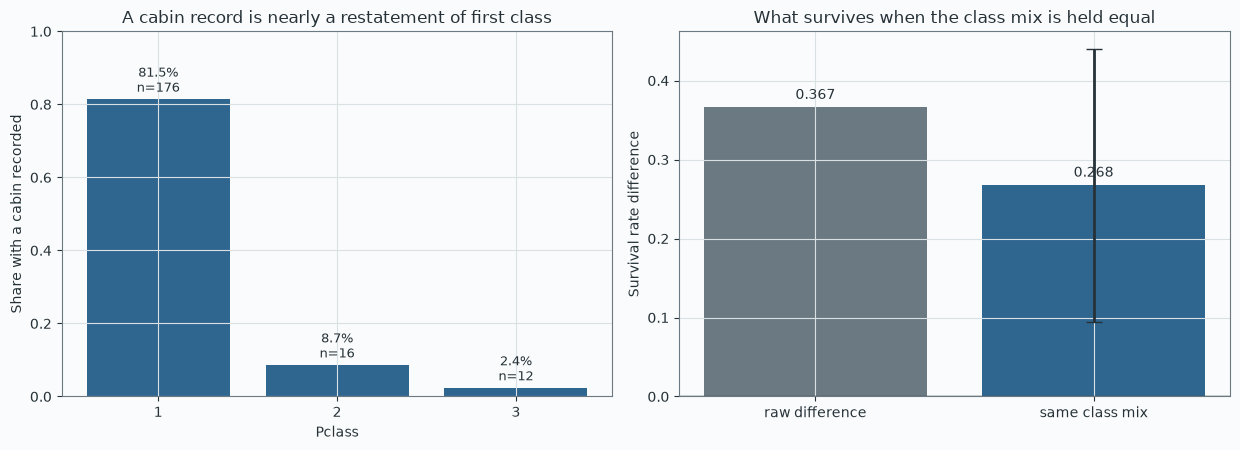

- 素の差は `0.3668`。等級構成を揃えると `0.2684`、95%区間 `[0.0948, 0.4404]`。  
- 差の `0.0984`（素の差の 27%）は等級構成の違いで説明できる。残りは残るが、区間の幅は`0.35` あり、大きさは絞れていない。

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

axes[0].bar(
    within["Pclass"].astype(str),
    within["recorded_share"],
    color=COLORS["blue"],
)
for row in within.itertuples():
    axes[0].text(
        str(row.Pclass), row.recorded_share + 0.02,
        f"{row.recorded_share:.1%}\nn={row.n_recorded}",
        ha="center", fontsize=9, color=COLORS["ink"],
    )
axes[0].set_ylim(0, 1.0)
axes[0].set_xlabel("Pclass")
axes[0].set_ylabel("Share with a cabin recorded")
axes[0].set_title("A cabin record is nearly a restatement of first class")

labels = ["raw difference", "same class mix"]
values = [raw_difference, standardized]
axes[1].bar(labels, values, color=[COLORS["muted"], COLORS["blue"]])
axes[1].errorbar(
    [1], [standardized],
    yerr=error_bar_widths([standardized], [standardized_low], [standardized_high]),
    fmt="none", ecolor=COLORS["ink"], elinewidth=2, capsize=6,
)
axes[1].axhline(0, color=COLORS["ink"], linewidth=1)
for position, value in enumerate(values):
    axes[1].text(
        position, value + 0.01, f"{value:.3f}",
        ha="center", fontsize=10, color=COLORS["ink"],
    )
axes[1].set_ylabel("Survival rate difference")
axes[1].set_title("What survives when the class mix is held equal")

figure.tight_layout()
plt.show()

display(Markdown(
    f"- 素の差は `{raw_difference:.4f}`。等級構成を揃えると `{standardized:.4f}`、"
    f"95%区間 `[{standardized_low:.4f}, {standardized_high:.4f}]`。  \n"
    f"- 差の `{raw_difference - standardized:.4f}`"
    f"（素の差の {100 * (raw_difference - standardized) / raw_difference:.0f}%）は"
    "等級構成の違いで説明できる。残りは残るが、区間の幅は"
    f"`{standardized_high - standardized_low:.2f}` あり、大きさは絞れていない。"
))

交絡を確認しても、`Cabin` を使うかどうかはまだ決まりません。観察が答えるのは
「関係がありそうか」までです。**採否は、比較の土俵を固定して初めて決まります。**
それを7節以降で行います。

> **English:** Roughly a quarter of the raw gap is explained by class composition and the rest
> remains, but the interval is wide. Observation narrows the candidates; it does not decide.

## 4. 指標を選ぶ / Choosing the metric

生存率は0.38で、クラスは偏っています。この偏りで accuracy が壊れるかを確認します。

判断は3点で決めます。**自明な基準線を超えるか**、**誤りのコストが非対称か**、
**外部の評価軸は何か**です。

In [7]:
majority_accuracy = 1 - y.mean()
majority_balanced = 0.5

metric_table = pd.DataFrame({
    "check": [
        "trivial baseline: predict everyone died",
        "accuracy of that trivial baseline",
        "balanced accuracy of that trivial baseline",
        "competition metric",
    ],
    "value": [
        f"{int((y == 0).sum())} / {len(y)}",
        f"{majority_accuracy:.4f}",
        f"{majority_balanced:.4f}",
        "accuracy",
    ],
})
display(metric_table)

,check,value
0,trivial baseline: predict everyone died,549 / 891
1,accuracy of that trivial baseline,0.6162
2,balanced accuracy of that trivial baseline,0.5000
3,competition metric,accuracy


全員を死亡と予測すると accuracy は約 `0.62` です。この後で出てくる `0.81` はこれを大きく
超えるので、指標として機能しています。99対1のデータなら自明基準が `0.99` になり、
そこでは accuracy は使えません。0.38は軽度の偏りで、質が違います。

2種類の誤りのコストはどうでしょうか。生存者を死亡と予測する誤りと、その逆です。
これは過去の名簿から生存を当てる課題であり、救助の意思決定ではありません。
**非対称なコストを置く根拠がありません。** 根拠なく balanced accuracy へ変えると、
少数クラスを暗黙に重く見ることになります。

そこで役割を分けます。**主指標は accuracy、採否の判断はこれだけで行う。**
混同行列の内訳は副指標として、何が起きたかの説明にだけ使い、採否には使いません。
複数の指標で判断してよいことにすると、結果を見てから都合の良い指標を選べてしまいます。

> **English:** The trivial baseline scores about 0.62, so accuracy still discriminates. There is
> no basis for asymmetric error costs in this task, and the competition metric is accuracy.
> Confusion-matrix detail is kept as description only, never as a second decision criterion.

## 5. ベースラインと共通の道具 / Baseline and shared machinery

特徴量は8列です。`CabinKnown` は `Cabin` の有無を表す0/1で、7節で比較対象になります。
前処理はすべてPipeline内に置き、**各foldの学習部分だけでfit**します。中央値も
One-Hotのカテゴリも、検証行から得ません。

In [8]:
BASE_FEATURES = [
    "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "CabinKnown",
]
prepared = train.assign(CabinKnown=train["Cabin"].notna().astype(int))


def build_pipeline(features: pd.DataFrame, max_depth) -> Pipeline:
    numeric_columns = features.select_dtypes(include="number").columns.tolist()
    categorical_columns = features.select_dtypes(exclude="number").columns.tolist()
    preprocess = ColumnTransformer([
        (
            "numeric",
            Pipeline([("imputer", SimpleImputer(strategy="median"))]),
            numeric_columns,
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_columns,
        ),
    ])
    return Pipeline([
        ("preprocess", preprocess),
        (
            "model",
            DecisionTreeClassifier(max_depth=max_depth, random_state=TREE_RANDOM_STATE),
        ),
    ])


def evaluate(features: pd.DataFrame, max_depth, seeds, collect_predictions=False):
    """同一のfoldでfoldごとの正解率を返す。腕をまたいで同じfoldを使うのが要点。"""
    records = []
    predictions = []
    for seed in seeds:
        splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
        for fold_number, (train_index, valid_index) in enumerate(
            splitter.split(features, y), start=1
        ):
            pipeline = build_pipeline(features, max_depth)
            pipeline.fit(features.iloc[train_index], y.iloc[train_index])
            predicted = pipeline.predict(features.iloc[valid_index])
            actual = y.iloc[valid_index].to_numpy()
            records.append({
                "seed": seed,
                "fold": fold_number,
                "accuracy": (predicted == actual).mean(),
                "train_accuracy": (
                    pipeline.predict(features.iloc[train_index])
                    == y.iloc[train_index].to_numpy()
                ).mean(),
                "leaves": int(pipeline.named_steps["model"].get_n_leaves()),
            })
            if collect_predictions:
                predictions.append(pd.DataFrame({
                    "seed": seed,
                    "index": valid_index,
                    "actual": actual,
                    "predicted": predicted,
                }))
    folds = pd.DataFrame(records)
    if collect_predictions:
        return folds, pd.concat(predictions, ignore_index=True)
    return folds


def paired_summary(by_fold: pd.DataFrame, reference: str) -> pd.DataFrame:
    """同じfoldでの対応のある差。fold共通のばらつきは引き算で消える。"""
    rows = []
    for column in by_fold.columns:
        delta = (by_fold[column] - by_fold[reference]).to_numpy()
        deviation = delta.std(ddof=1)
        standard_error = deviation / np.sqrt(delta.size) if deviation > 0 else 0.0
        rows.append({
            "arm": column,
            "folds": delta.size,
            "mean_difference": delta.mean(),
            "se": standard_error,
            "ci_low": delta.mean() - 2 * standard_error,
            "ci_high": delta.mean() + 2 * standard_error,
        })
    return pd.DataFrame(rows)


print("features:", len(BASE_FEATURES))

features: 8


## 6. 誤りの向きを見る / The direction of the errors

採否には使いませんが、ベースラインが何を間違えるかを先に見ておきます。
深さ3の木で、全891行のOut-of-Fold予測を作ります。

In [9]:
BASELINE_DEPTH = 3
baseline_folds, baseline_predictions = evaluate(
    prepared[BASE_FEATURES], BASELINE_DEPTH, [TREE_RANDOM_STATE], collect_predictions=True
)
baseline_predictions = baseline_predictions.assign(
    error_type=np.select(
        [
            (baseline_predictions["actual"] == 1) & (baseline_predictions["predicted"] == 0),
            (baseline_predictions["actual"] == 0) & (baseline_predictions["predicted"] == 1),
        ],
        ["missed survivor", "false survivor"],
        default="correct",
    )
)
joined = baseline_predictions.join(
    train[["Pclass", "Sex"]].reset_index(drop=True), on="index"
)
error_grid = (
    joined.assign(is_error=(joined["error_type"] != "correct").astype(int))
    .groupby(["Pclass", "Sex"])
    .agg(error_rate=("is_error", "mean"), passengers=("is_error", "size"))
    .reset_index()
)
counts = joined["error_type"].value_counts()

display(error_grid.round(4))
display(Markdown(
    f"- OOF正解率 `{baseline_folds['accuracy'].mean():.4f}`。  \n"
    f"- 誤りの内訳は missed survivor `{int(counts.get('missed survivor', 0))}` 件、"
    f"false survivor `{int(counts.get('false survivor', 0))}` 件。  \n"
    f"- 層別の誤分類率は "
    f"`{error_grid['error_rate'].min():.3f}` から `{error_grid['error_rate'].max():.3f}` まで開く。"
    "平均だけでは、誤りがどこに集中しているかは見えない。"
))

,Pclass,Sex,error_rate,passengers
0,1,female,0.0319,94
1,1,male,0.3934,122
2,2,female,0.1053,76
3,2,male,0.1019,108
4,3,female,0.3542,144
5,3,male,0.1412,347


- OOF正解率 `0.8092`。  
- 誤りの内訳は missed survivor `98` 件、false survivor `72` 件。  
- 層別の誤分類率は `0.032` から `0.393` まで開く。平均だけでは、誤りがどこに集中しているかは見えない。

## 7. 比較1: `Cabin` の表現 / Comparison 1: encoding Cabin

### 事前登録 / Registered before running

| 項目 | 内容 |
|---|---|
| 腕 | 落とす（7列）/ 有無フラグ（8列、現行）/ デッキ（先頭文字、欠損は `Missing` 水準） |
| 基準腕 | 有無フラグ |
| 深さ | 3〜8。**頑健性の軸であり、選択には使わない** |
| 分割 | 層化5-fold × 5 seed = 25 fold、全腕で同一 |
| 採用条件 | ペア差の95%区間が0を含まず、かつ平均 `+0.015` 以上 |
| 頑健性 | 上を6深さ中5以上で満たすこと |

`+0.015` は乗客およそ13人ぶんです。この設計で測れる下限は片側 `0.007` 程度なので、
閾値はそれを上回るように置きました。

> **English:** Arms, reference, depths, folds and the adoption rule were fixed before running.
> Depth is a robustness axis, not a selection axis, which keeps the selection freedom at two
> comparisons rather than eighteen.

In [10]:
CABIN_SEEDS = [0, 1, 2, 3, 42]
CABIN_DEPTHS = [3, 4, 5, 6, 7, 8]
MINIMUM_GAIN = 0.015
REQUIRED_DEPTHS = 5

cabin_arms = {
    "drop": prepared[[c for c in BASE_FEATURES if c != "CabinKnown"]],
    "presence flag": prepared[BASE_FEATURES],
    "deck": prepared[[c for c in BASE_FEATURES if c != "CabinKnown"]].assign(
        Deck=train["Cabin"].str[0].fillna("Missing")
    ),
}
CABIN_REFERENCE = "presence flag"

cabin_records = []
for depth in CABIN_DEPTHS:
    folds = {
        name: evaluate(features, depth, CABIN_SEEDS).set_index(["seed", "fold"])["accuracy"]
        for name, features in cabin_arms.items()
    }
    by_fold = pd.DataFrame(folds)
    summary = paired_summary(by_fold, CABIN_REFERENCE)
    summary["depth"] = depth
    summary["mean_accuracy"] = [by_fold[name].mean() for name in summary["arm"]]
    cabin_records.append(summary)

cabin_results = pd.concat(cabin_records, ignore_index=True)
cabin_results["excludes_zero"] = ~(
    (cabin_results["ci_low"] < 0) & (0 < cabin_results["ci_high"])
)
cabin_results["meets_gain"] = cabin_results["mean_difference"] >= MINIMUM_GAIN
cabin_results["adopt"] = cabin_results["excludes_zero"] & cabin_results["meets_gain"]

display(
    cabin_results.pivot(index="depth", columns="arm", values="mean_accuracy").round(4)
)

arm,deck,drop,presence flag
depth,,,
3,0.8081,0.8182,0.8085
4,0.8056,0.8114,0.8072
5,0.8063,0.8101,0.8063
6,0.8067,0.8153,0.8076
7,0.8090,0.8148,0.8045
8,0.8061,0.8188,0.8085


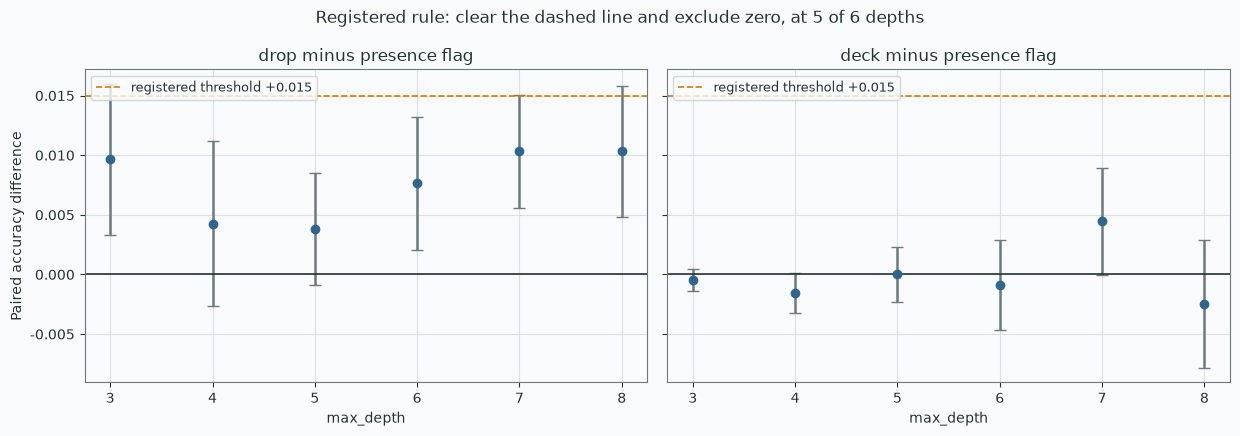

- `drop`: 条件を満たした深さ `0/6`（基準 5/6）→ **採用しない**
- `deck`: 条件を満たした深さ `0/6`（基準 5/6）→ **採用しない**  
- ただし `drop` は6深さすべてで正の差だった（`+0.0038` 〜 `+0.0103`）。区間が0を含まなかったのは `4/6`。

In [11]:
comparisons = [name for name in cabin_arms if name != CABIN_REFERENCE]
figure, axes = plt.subplots(1, len(comparisons), figsize=(12.5, 4.4), sharey=True)

for axis, arm_name in zip(np.atleast_1d(axes), comparisons):
    subset = cabin_results[cabin_results["arm"] == arm_name].sort_values("depth")
    positions = np.arange(len(subset))
    axis.errorbar(
        positions,
        subset["mean_difference"],
        yerr=error_bar_widths(
            subset["mean_difference"], subset["ci_low"], subset["ci_high"]
        ),
        fmt="o", color=COLORS["blue"], ecolor=COLORS["muted"],
        elinewidth=1.8, capsize=4,
    )
    axis.axhline(0, color=COLORS["ink"], linewidth=1.2)
    axis.axhline(
        MINIMUM_GAIN, color=COLORS["orange"], linestyle="--", linewidth=1.2,
        label=f"registered threshold +{MINIMUM_GAIN}",
    )
    axis.set_xticks(positions)
    axis.set_xticklabels(subset["depth"])
    axis.set_xlabel("max_depth")
    axis.set_title(f"{arm_name} minus {CABIN_REFERENCE}")
    axis.legend(fontsize=9, loc="upper left")

np.atleast_1d(axes)[0].set_ylabel("Paired accuracy difference")
figure.suptitle("Registered rule: clear the dashed line and exclude zero, at 5 of 6 depths")
figure.tight_layout()
plt.show()

verdicts = []
for arm_name in comparisons:
    subset = cabin_results[cabin_results["arm"] == arm_name]
    satisfied = int(subset["adopt"].sum())
    verdicts.append(
        f"- `{arm_name}`: 条件を満たした深さ `{satisfied}/{len(CABIN_DEPTHS)}`"
        f"（基準 {REQUIRED_DEPTHS}/{len(CABIN_DEPTHS)}）→ "
        f"**{'採用' if satisfied >= REQUIRED_DEPTHS else '採用しない'}**"
    )
drop_subset = cabin_results[cabin_results["arm"] == "drop"]
display(Markdown(
    "\n".join(verdicts)
    + f"  \n- ただし `drop` は6深さすべてで正の差だった"
    f"（`{drop_subset['mean_difference'].min():+.4f}` 〜 "
    f"`{drop_subset['mean_difference'].max():+.4f}`）。"
    f"区間が0を含まなかったのは `{int(drop_subset['excludes_zero'].sum())}/6`。"
))

### 判定ルールが結論を決めていた / The rule decided this one

登録した基準では、どちらの腕も採用されません。**結論は「現行の有無フラグを維持」です。**

しかし `drop` は6深さすべてで現行を上回りました。閾値 `+0.015` に届かなかっただけです。
ここで、登録した基準に欠陥があったことが分かります。**`+0.015` は「複雑さを足す代償」として
置いた値でしたが、実際に上回ったのは複雑さを減らす方向でした。** 減らす方向にも同じ
閾値を課すのが妥当かは、設計時に考えていませんでした。

ここで基準を緩めれば `drop` が採用側に寄ります。しかしそれは結果を見てから基準を動かす
ことです。**今回は登録どおり判定し、非対称性は次の設計へ持ち越します。**

参考として、別の確立した基準ならどうなるかを併記します。1標準誤差ルール
（最良から1SE以内で最も単純なものを選ぶ）は、決定木の枝刈りで標準的に使われます。
この規則では `drop` は単純かつ平均が高いので、6深さすべてで選ばれます。

**同じデータで、決定ルールの形が結論を反転させました。** 今日の「採用しない」は、
事前登録した基準の下では正しい結論です。同時に、別の基準なら別の結論になったことも事実です。

> **English:** Under the registered rule nothing is adopted. Under a 1-SE style rule the drop arm
> would be selected at every depth. Both statements are true; the registered one is the decision.

## 8. 比較2: 家族による情報の漏れ / Comparison 2: family straddling

`Ticket` と `Name` の姓が同じ乗客は、同じ家族である可能性が高くなります。家族が学習側と
検証側に分かれると、検証の正解率は上振れするはずです。モデルは `Ticket` も姓も持っていませんが、
家族は `Fare`（チケット単位の金額）、`Pclass`、`Embarked` の値がほぼ一致するため、
木がその家族だけを含む葉を作れます。

まず前提を確認します。**グループ内で結果が相関しているか**と、**露出がどれだけあるか**です。

In [12]:
surname = train["Name"].str.split(",").str[0].str.strip()
parent = {index: index for index in train.index}


def find(node: int) -> int:
    while parent[node] != node:
        parent[node] = parent[parent[node]]
        node = parent[node]
    return node


def union(left: int, right: int) -> None:
    root_left, root_right = find(left), find(right)
    if root_left != root_right:
        parent[root_right] = root_left


for keys in [train["Ticket"], surname]:
    for _, indices in train.groupby(keys).groups.items():
        members = list(indices)
        for other in members[1:]:
            union(members[0], other)

groups = pd.Series([find(index) for index in train.index], index=train.index)

concordance = []
for _, part in train.groupby(groups):
    values = part[TARGET_COLUMN].to_numpy()
    size = len(values)
    if size < 2:
        continue
    alive = values.sum()
    concordance.append((alive**2 + (size - alive) ** 2 - size) / (size * (size - 1)))
unrelated = y.mean() ** 2 + (1 - y.mean()) ** 2

exposure = []
for seed in [0, 1, 2, 3, 42]:
    splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    for train_index, valid_index in splitter.split(train, y):
        training_groups = set(groups.iloc[train_index])
        exposure.append(groups.iloc[valid_index].isin(training_groups).mean())

display(Markdown(
    f"- 連結成分は `{groups.nunique()}` 個。2人以上の成分に属する乗客は "
    f"`{int((groups.map(groups.value_counts()) > 1).sum())}` 人"
    f"（{(groups.map(groups.value_counts()) > 1).mean():.1%}）。  \n"
    f"- 同じ成分の2人が生死で一致する割合 `{np.mean(concordance):.1%}`、"
    f"無関係な2人なら `{unrelated:.1%}`。**結果は相関している。**  \n"
    f"- 現行の分割で、検証行のうち学習側に仲間がいる割合 `{np.mean(exposure):.1%}`。"
    "**露出も大きい。** 前提は2つとも成立している。"
))

- 連結成分は `609` 個。2人以上の成分に属する乗客は `438` 人（49.2%）。  
- 同じ成分の2人が生死で一致する割合 `69.3%`、無関係な2人なら `52.7%`。**結果は相関している。**  
- 現行の分割で、検証行のうち学習側に仲間がいる割合 `44.6%`。**露出も大きい。** 前提は2つとも成立している。

### 事前登録と、一度目の失敗 / A failed design, kept

最初は5 seedで測りました。腕は `drop` と `presence flag` の2つ、深さ3、
通常の層化5-foldと `StratifiedGroupKFold` の差を上振れの推定量とします。

結果、推定値は正の側に寄りましたが、**seed間のばらつきが推定値より大きく、判定できません
でした。** 解釈の基準は事前に置いたのに、**その基準を判定できる精度が設計にあるかを
見積もっていませんでした。**

そこで追加の25 seed（5〜29）を登録し直しました。判定は追加25 seedだけで行います。
最初の5 seedは「正の側に寄っている」と見た上で継続を決めた材料なので、含めると
継続判断の影響が混ざります。事前に計算した検出下限は `2SE ≒ 0.0035` でした。

In [13]:
EXPLORATORY_SEEDS = [0, 1, 2, 3, 42]
REGISTERED_SEEDS = list(range(5, 30))
LEAK_ARMS = {"drop": cabin_arms["drop"], "presence flag": cabin_arms["presence flag"]}


def grouped_accuracy(features: pd.DataFrame, seed: int) -> float:
    splitter = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    correct = []
    for train_index, valid_index in splitter.split(features, y, groups):
        pipeline = build_pipeline(features, BASELINE_DEPTH)
        pipeline.fit(features.iloc[train_index], y.iloc[train_index])
        correct.append(
            pipeline.predict(features.iloc[valid_index]) == y.iloc[valid_index].to_numpy()
        )
    return float(np.concatenate(correct).mean())


leak_records = []
for arm_name, features in LEAK_ARMS.items():
    for seed in EXPLORATORY_SEEDS + REGISTERED_SEEDS:
        stratified = evaluate(features, BASELINE_DEPTH, [seed])["accuracy"].mean()
        leak_records.append({
            "arm": arm_name,
            "seed": seed,
            "registered": seed in REGISTERED_SEEDS,
            "inflation": stratified - grouped_accuracy(features, seed),
        })

leakage = pd.DataFrame(leak_records)


def describe(values: np.ndarray) -> dict:
    standard_error = values.std(ddof=1) / np.sqrt(values.size)
    return {
        "seeds": values.size,
        "mean": values.mean(),
        "se": standard_error,
        "mean_minus_2se": values.mean() - 2 * standard_error,
    }


judged = leakage[(leakage["arm"] == "drop") & leakage["registered"]]["inflation"].to_numpy()
explored = leakage[(leakage["arm"] == "drop") & ~leakage["registered"]]["inflation"].to_numpy()
pooled = leakage[leakage["arm"] == "drop"]["inflation"].to_numpy()
judgement = describe(judged)

display(pd.DataFrame([
    {"set": "exploratory 5 seeds (not judged)", **describe(explored)},
    {"set": "registered 25 seeds (judged)", **judgement},
    {"set": "all 30 pooled (reference only)", **describe(pooled)},
]).round(5))

,set,seeds,mean,se,mean_minus_2se
0,exploratory 5 seeds (not judged),5,0.00874,0.00384,0.00105
1,registered 25 seeds (judged),25,0.00413,0.00173,0.00067
2,all 30 pooled (reference only),30,0.00490,0.00158,0.00173


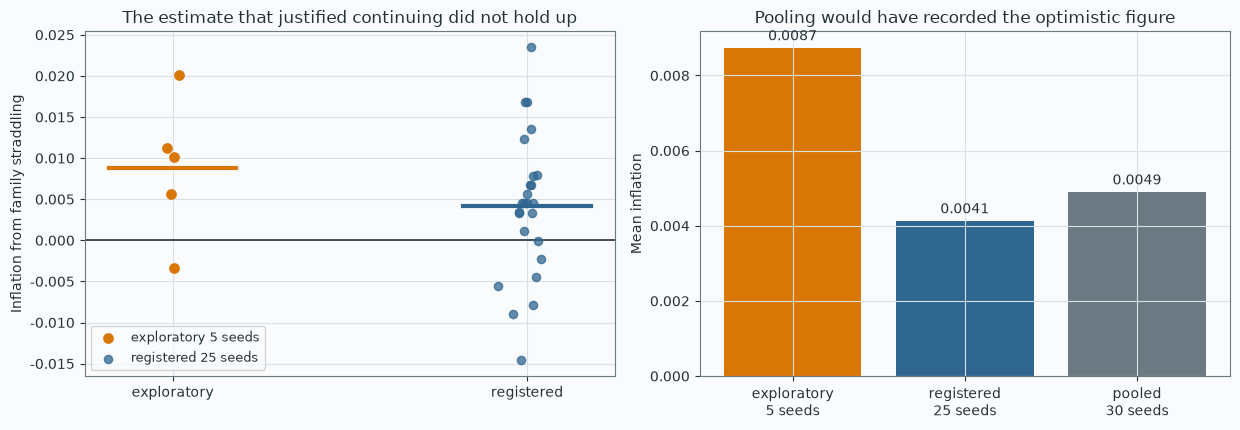

- 登録した判定: 平均 `+0.00413`、平均−2SE `+0.00067` → **上振れを検出**。実際の検出下限は `2SE = 0.00346`。  
- 探索5 seedの `+0.0087` が、独立な25 seedでは `+0.0041` になった。30 seedをまとめると `+0.0049` で、継続を決めた標本が混ざるぶん楽観側へ寄る。  
- **腕間の上振れの差は `+0.00144`** で、検出下限 `0.00346` を下回る。上振れは両方の腕にほぼ同じだけ乗っており、腕どうしの引き算でほぼ消える。7節の結論を読み直す必要はない。  
- この節の数値はライブラリ版によって変動する。`StratifiedGroupKFold` のfold割り当てが版によって変わるためで、結論の向きは変わらないが、値は実行環境に依存する。

In [14]:
figure, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

axes[0].scatter(
    np.zeros(explored.size) + np.random.default_rng(0).normal(0, 0.03, explored.size),
    explored, s=45, color=COLORS["orange"], label="exploratory 5 seeds", zorder=3,
)
axes[0].scatter(
    np.ones(judged.size) + np.random.default_rng(1).normal(0, 0.03, judged.size),
    judged, s=35, color=COLORS["blue"], alpha=0.75, label="registered 25 seeds", zorder=3,
)
for position, values, color in [(0, explored, COLORS["orange"]), (1, judged, COLORS["blue"])]:
    axes[0].plot([position - 0.18, position + 0.18], [values.mean()] * 2,
                 color=color, linewidth=3)
axes[0].axhline(0, color=COLORS["ink"], linewidth=1.2)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["exploratory", "registered"])
axes[0].set_ylabel("Inflation from family straddling")
axes[0].set_title("The estimate that justified continuing did not hold up")
axes[0].legend(fontsize=9)

bars = ["exploratory\n5 seeds", "registered\n25 seeds", "pooled\n30 seeds"]
heights = [explored.mean(), judged.mean(), pooled.mean()]
axes[1].bar(bars, heights, color=[COLORS["orange"], COLORS["blue"], COLORS["muted"]])
for position, height in enumerate(heights):
    axes[1].text(position, height + 0.0002, f"{height:.4f}",
                 ha="center", fontsize=10, color=COLORS["ink"])
axes[1].set_ylabel("Mean inflation")
axes[1].set_title("Pooling would have recorded the optimistic figure")

figure.tight_layout()
plt.show()

arm_gap = (
    leakage[(leakage["arm"] == "drop") & leakage["registered"]]["inflation"].mean()
    - leakage[(leakage["arm"] == "presence flag") & leakage["registered"]]["inflation"].mean()
)
display(Markdown(
    f"- 登録した判定: 平均 `{judgement['mean']:+.5f}`、"
    f"平均−2SE `{judgement['mean_minus_2se']:+.5f}` → "
    f"**{'上振れを検出' if judgement['mean_minus_2se'] > 0 else '検出されず'}**。"
    f"実際の検出下限は `2SE = {2 * judgement['se']:.5f}`。  \n"
    f"- 探索5 seedの `{explored.mean():+.4f}` が、独立な25 seedでは "
    f"`{judged.mean():+.4f}` になった。30 seedをまとめると `{pooled.mean():+.4f}` で、"
    "継続を決めた標本が混ざるぶん楽観側へ寄る。  \n"
    f"- **腕間の上振れの差は `{arm_gap:+.5f}`** で、検出下限 `{2 * judgement['se']:.5f}` を"
    f"{'下回る' if abs(arm_gap) < 2 * judgement['se'] else '上回る'}。"
    "上振れは両方の腕にほぼ同じだけ乗っており、腕どうしの引き算でほぼ消える。"
    "7節の結論を読み直す必要はない。  \n"
    "- この節の数値はライブラリ版によって変動する。`StratifiedGroupKFold` の"
    "fold割り当てが版によって変わるためで、結論の向きは変わらないが、値は実行環境に依存する。"
))

上振れは検出されましたが、大きさは事前に置いた解釈基準の最下段に収まっています。
その基準は「`0.007` 未満は記録するが読み方は変えない」でした。**統計的に検出できることと、
実質的に意味があることは別です。**

そして比較への影響はさらに小さく、腕間の差は上の実行値のとおり検出下限を下回ります。
**漏れは存在するが、腕どうしを比べる用途では引き算でほぼ消えていた**、というのが結論です。

> **English:** Leakage is real and small. What matters for arm comparison is not its level but
> whether it differs between arms, and it barely does.

## 9. 比較3: `Age` の欠損 / Comparison 3: filling missing Age

`Age` は177行（約20%）が欠損しています。中央値で埋めると、**177人全員が28.0歳ちょうど**に
なります。群別中央値は21.5歳から40.0歳まで開くので、全体中央値はかなり粗い代入です。

### 事前登録 / Registered before running

| 項目 | 内容 |
|---|---|
| 腕 | Age落とす(10列) / 全体中央値(11列、現行) / 群別中央値 `[Pclass, Sex]`(11列) / 中央値+欠損フラグ(12列) |
| 深さ | 3に固定。頑健性は本比較では未検証 |
| 分割 | 層化5-fold × 20 seed = 100 fold |
| 判定 | ペア差版の1-SEルール |
| 単純さ | 第1優先は列数、同数なら前処理の段数が少ない方 |

ここで判定ルールを差し替えました。古典的な1-SEルールは1つの腕のfold間のばらつきから
SEを作るため、100 foldでも `0.0025` 程度になります。腕間の差より大きいので、
**データによらず最少列数の腕が選ばれてしまいます。** 同じfoldでのペア差を使えば、
fold共通のばらつきが消え、表現の違いだけのSEで判定できます。

In [15]:
AGE_SEEDS = list(range(20))
GROUP_COLUMNS = ["Pclass", "Sex"]


class GroupMedianImputer:
    """[Pclass, Sex] ごとの中央値でAgeを埋める。学習部分だけで中央値を推定する。"""

    def __init__(self, target_column="Age"):
        self.target_column = target_column

    def get_params(self, deep=True):
        return {"target_column": self.target_column}

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

    def fit(self, X, y=None):
        observed = X.dropna(subset=[self.target_column])
        self.group_medians_ = observed.groupby(GROUP_COLUMNS)[self.target_column].median()
        self.global_median_ = observed[self.target_column].median()
        return self

    def transform(self, X):
        frame = X.copy()
        missing = frame[self.target_column].isna()
        if missing.any():
            keys = pd.MultiIndex.from_frame(frame.loc[missing, GROUP_COLUMNS])
            filled = self.group_medians_.reindex(keys).to_numpy()
            filled = np.where(np.isnan(filled), self.global_median_, filled)
            frame.loc[missing, self.target_column] = filled
        return frame

    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)


age_arms = {
    "drop Age": prepared[[c for c in BASE_FEATURES if c != "Age"]],
    "global median": prepared[BASE_FEATURES],
    "group median": prepared[BASE_FEATURES],
    "median + flag": prepared[BASE_FEATURES].assign(
        AgeMissing=train["Age"].isna().astype(int)
    ),
}
age_columns = {"drop Age": 10, "global median": 11, "group median": 11, "median + flag": 12}
age_steps = {"drop Age": 0, "global median": 0, "group median": 1, "median + flag": 0}

age_folds = {}
for arm_name, features in age_arms.items():
    # 群別中央値の腕だけは、中央値を学習部分だけから推定するため
    # foldごとにimputerをfitし直す。全データでのfitは行わない。
    if arm_name == "group median":
        records = []
        for seed in AGE_SEEDS:
            splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
            for fold_number, (train_index, valid_index) in enumerate(
                splitter.split(features, y), start=1
            ):
                imputer = GroupMedianImputer().fit(features.iloc[train_index])
                pipeline = build_pipeline(features, BASELINE_DEPTH)
                pipeline.fit(imputer.transform(features.iloc[train_index]), y.iloc[train_index])
                predicted = pipeline.predict(imputer.transform(features.iloc[valid_index]))
                records.append({
                    "seed": seed,
                    "fold": fold_number,
                    "accuracy": (predicted == y.iloc[valid_index].to_numpy()).mean(),
                })
        folds = pd.DataFrame(records)
    else:
        folds = evaluate(features, BASELINE_DEPTH, AGE_SEEDS)
    age_folds[arm_name] = folds.set_index(["seed", "fold"])["accuracy"]

age_by_fold = pd.DataFrame(age_folds)
age_best = age_by_fold.mean().idxmax()
age_summary = paired_summary(age_by_fold, age_best)
age_summary["mean_accuracy"] = [age_by_fold[name].mean() for name in age_summary["arm"]]
# paired_summary は「腕 − 基準」を返す。基準が最良腕なので、判定に使うのは
# 符号を戻した「最良からの不足分」。ここを取り違えると全腕が閾値内に入る。
age_summary["deficit"] = -age_summary["mean_difference"]
age_summary["within_1se"] = age_summary["deficit"] <= age_summary["se"]
age_summary["encoded_columns"] = age_summary["arm"].map(age_columns)
age_summary["steps"] = age_summary["arm"].map(age_steps)

display(age_summary[
    ["arm", "mean_accuracy", "deficit", "se", "within_1se", "encoded_columns", "steps"]
].round(5))

age_selected = (
    age_summary[age_summary["within_1se"]]
    .sort_values(["encoded_columns", "steps"])
    .iloc[0]
)
display(Markdown(
    f"- 最良は `{age_best}`。1SE以内は "
    f"`{', '.join(age_summary[age_summary['within_1se']]['arm'])}`。  \n"
    f"- **選択: `{age_selected['arm']}`**"
    f"（{int(age_selected['encoded_columns'])}列、前処理 {int(age_selected['steps'])}段）。"
    "現行の扱いが残った。  \n"
    f"- `drop Age` の不足分は `{age_summary.loc[age_summary['arm'] == 'drop Age', 'deficit'].iloc[0]:.5f}`、"
    f"SEの約 "
    f"{age_summary.loc[age_summary['arm'] == 'drop Age', 'deficit'].iloc[0] / age_summary.loc[age_summary['arm'] == 'drop Age', 'se'].iloc[0]:.1f} 倍で、"
    "唯一はっきり外れた腕。**`Age` には情報がある。** 一方、埋め方の違いは判別できなかった。"
))

,arm,mean_accuracy,deficit,se,within_1se,encoded_columns,steps
0,drop Age,0.80466,0.00522,0.00139,False,10,0
1,global median,0.80960,0.00028,0.00034,True,11,0
2,group median,0.80976,0.00011,0.00056,True,11,1
3,median + flag,0.80988,-0.00000,0.00000,True,12,0


- 最良は `median + flag`。1SE以内は `global median, group median, median + flag`。  
- **選択: `global median`**（11列、前処理 0段）。現行の扱いが残った。  
- `drop Age` の不足分は `0.00522`、SEの約 3.8 倍で、唯一はっきり外れた腕。**`Age` には情報がある。** 一方、埋め方の違いは判別できなかった。

## 10. 比較4: 木の深さ / Comparison 4: tree depth

### 事前登録 / Registered before running

候補は深さ1〜10と制限なしの11通り、20 seed × 5-fold = 100 fold、判定はペア差版の
1-SEルール。**単純さは平均の葉の数で測ります**（列数は全候補で同じなので、
従来の基準が機能しないため）。

候補範囲には、既存の材料から悪いと分かっている深さ1・2や制限なしも含めます。
範囲を狭めると、結論を先取りすることになるためです。

In [16]:
DEPTH_SEEDS = list(range(20))
DEPTH_GRID = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, None]
DEPTH_LABELS = ["unlimited" if depth is None else str(depth) for depth in DEPTH_GRID]

depth_folds = {}
depth_rows = []
for depth, label in zip(DEPTH_GRID, DEPTH_LABELS):
    folds = evaluate(prepared[BASE_FEATURES], depth, DEPTH_SEEDS)
    depth_folds[label] = folds.set_index(["seed", "fold"])["accuracy"]
    depth_rows.append({
        "depth": label,
        "validation_mean": folds["accuracy"].mean(),
        "train_mean": folds["train_accuracy"].mean(),
        "leaves_mean": folds["leaves"].mean(),
    })

depth_by_fold = pd.DataFrame(depth_folds)
depth_table = pd.DataFrame(depth_rows).set_index("depth")
depth_table["train_minus_validation"] = (
    depth_table["train_mean"] - depth_table["validation_mean"]
)

depth_best = depth_table["validation_mean"].idxmax()
depth_summary = paired_summary(depth_by_fold, depth_best)
depth_summary["deficit"] = -depth_summary["mean_difference"]
depth_summary["within_1se"] = depth_summary["deficit"] <= depth_summary["se"]
depth_summary["leaves_mean"] = depth_summary["arm"].map(depth_table["leaves_mean"])

display(depth_table.round(4))

depth_selected = (
    depth_summary[depth_summary["within_1se"]].sort_values("leaves_mean").iloc[0]
)

,validation_mean,train_mean,leaves_mean,train_minus_validation
depth,,,,
1,0.7868,0.7868,2.00,-0.0000
2,0.7744,0.7926,4.00,0.0183
3,0.8096,0.8257,8.00,0.0161
4,0.8111,0.8386,14.78,0.0276
5,0.8054,0.8531,23.72,0.0477
6,0.8055,0.8714,35.06,0.0658
7,0.8038,0.8882,48.60,0.0843
8,0.8034,0.9056,63.01,0.1022
9,0.8027,0.9207,78.78,0.1179


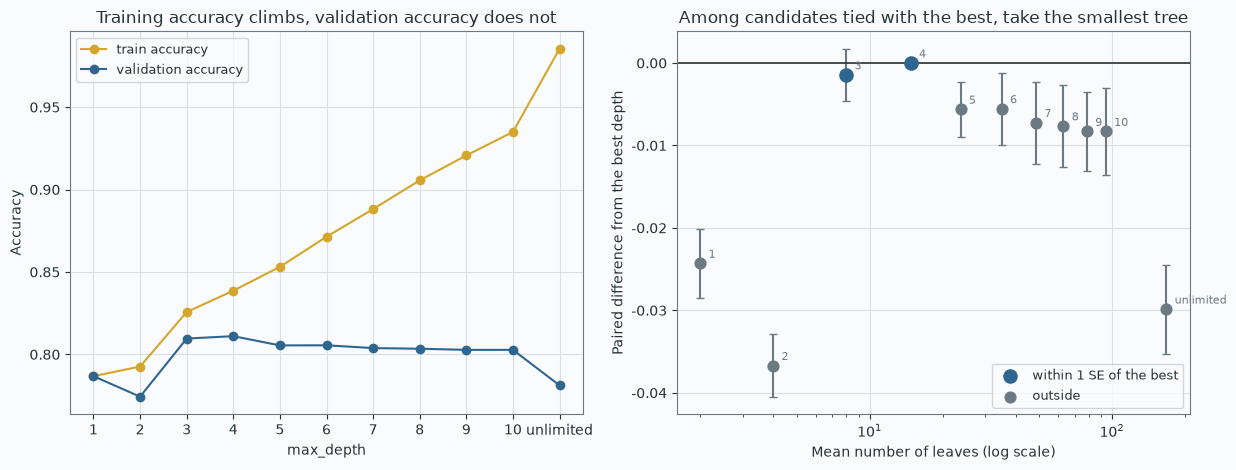

- 最良は深さ `4`（0.8111）。1SE以内は `3, 4`。  
- **選択: 深さ `3`**（平均の葉 8.0）。  
- 深さ2は深さ1より低い（0.7744 対 0.7868）。正解率は深さに対して単調ではない。

In [17]:
figure, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

positions = np.arange(len(DEPTH_LABELS))
axes[0].plot(positions, depth_table["train_mean"], marker="o",
             color=COLORS["gold"], label="train accuracy")
axes[0].plot(positions, depth_table["validation_mean"], marker="o",
             color=COLORS["blue"], label="validation accuracy")
axes[0].set_xticks(positions)
axes[0].set_xticklabels(DEPTH_LABELS)
axes[0].set_xlabel("max_depth")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Training accuracy climbs, validation accuracy does not")
axes[0].legend(fontsize=9)

ordered_depth = depth_summary.set_index("arm").loc[DEPTH_LABELS]
inside = ordered_depth["within_1se"].to_numpy()
axes[1].errorbar(
    ordered_depth["leaves_mean"], ordered_depth["mean_difference"],
    yerr=error_bar_widths(
        ordered_depth["mean_difference"], ordered_depth["ci_low"], ordered_depth["ci_high"]
    ),
    fmt="none", ecolor=COLORS["muted"], elinewidth=1.5, capsize=3,
)
axes[1].scatter(
    ordered_depth["leaves_mean"][inside], ordered_depth["mean_difference"][inside],
    s=90, color=COLORS["blue"], zorder=3, label="within 1 SE of the best",
)
axes[1].scatter(
    ordered_depth["leaves_mean"][~inside], ordered_depth["mean_difference"][~inside],
    s=60, color=COLORS["muted"], zorder=3, label="outside",
)
for label, row in ordered_depth.iterrows():
    axes[1].annotate(label, (row["leaves_mean"], row["mean_difference"]),
                     textcoords="offset points", xytext=(6, 4),
                     fontsize=8, color=COLORS["muted"])
axes[1].axhline(0, color=COLORS["ink"], linewidth=1.2)
axes[1].set_xscale("log")
axes[1].set_xlabel("Mean number of leaves (log scale)")
axes[1].set_ylabel("Paired difference from the best depth")
axes[1].set_title("Among candidates tied with the best, take the smallest tree")
axes[1].legend(fontsize=9)

figure.tight_layout()
plt.show()

display(Markdown(
    f"- 最良は深さ `{depth_best}`（{depth_table.loc[depth_best, 'validation_mean']:.4f}）。"
    f"1SE以内は `{', '.join(depth_summary[depth_summary['within_1se']]['arm'])}`。  \n"
    f"- **選択: 深さ `{depth_selected['arm']}`**"
    f"（平均の葉 {depth_selected['leaves_mean']:.1f}）。  \n"
    f"- 深さ2は深さ1より低い"
    f"（{depth_table.loc['2', 'validation_mean']:.4f} 対 "
    f"{depth_table.loc['1', 'validation_mean']:.4f}）。"
    "正解率は深さに対して単調ではない。"
))

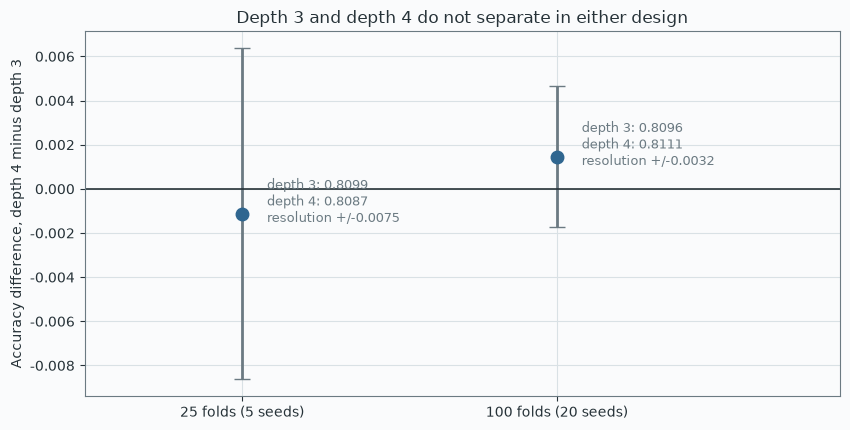

,design,folds,depth 3,depth 4,difference (4 - 3),resolution 2SE
0,25 folds (5 seeds),25,0.80987,0.80874,-0.00112,0.00751
1,100 folds (20 seeds),100,0.80960,0.81105,0.00146,0.00319


In [18]:
# 25 fold と 100 fold で、深さ3と4の順位を比べる
small_folds = depth_by_fold.loc[
    depth_by_fold.index.get_level_values("seed").isin(CABIN_SEEDS[:4] + [4])
]
resolution_rows = []
for label, subset in [("25 folds (5 seeds)", small_folds), ("100 folds (20 seeds)", depth_by_fold)]:
    delta = (subset["4"] - subset["3"]).to_numpy()
    standard_error = delta.std(ddof=1) / np.sqrt(delta.size)
    resolution_rows.append({
        "design": label,
        "folds": delta.size,
        "depth 3": subset["3"].mean(),
        "depth 4": subset["4"].mean(),
        "difference (4 - 3)": delta.mean(),
        "resolution 2SE": 2 * standard_error,
    })
resolution = pd.DataFrame(resolution_rows)

# 棒の高さを比べると軸を切る必要が出て差が誇張される。差そのものを分解能と並べる。
figure, axis = plt.subplots(figsize=(8.6, 4.4))
positions = np.arange(len(resolution))
for position, (_, row) in enumerate(resolution.iterrows()):
    axis.errorbar(
        position, row["difference (4 - 3)"],
        yerr=row["resolution 2SE"],
        fmt="o", markersize=9, color=COLORS["blue"],
        ecolor=COLORS["muted"], elinewidth=2, capsize=6,
    )
    axis.annotate(
        f"depth 3: {row['depth 3']:.4f}\n"
        f"depth 4: {row['depth 4']:.4f}\n"
        f"resolution +/-{row['resolution 2SE']:.4f}",
        (position, row["difference (4 - 3)"]),
        textcoords="offset points", xytext=(18, -6),
        fontsize=9, color=COLORS["muted"],
    )
axis.axhline(0, color=COLORS["ink"], linewidth=1.2)
axis.set_xlim(-0.5, len(resolution) - 0.1)
axis.set_xticks(positions)
axis.set_xticklabels(resolution["design"])
axis.set_ylabel("Accuracy difference, depth 4 minus depth 3")
axis.set_title("Depth 3 and depth 4 do not separate in either design")
figure.tight_layout()
plt.show()

display(resolution.round(5))

差の符号が入れ替わっています。25 foldでは深さ3が上、100 foldでは深さ4が上です。

ただし重要なのは、**どちらの設計でも誤差棒が0を跨いでいる**ことです。分解能は上の表のとおり
改善しましたが、この2つを分けるにはまだ足りません。つまり順位が入れ替わったのは、
**区別できていない差に順位を付けていたから**です。

深さ3を選んだのは、深さ4より良いと示せたからではありません。**区別がつかない中で、
葉の少ない方を取った**、というのが1-SEルールの意味です。

一方、深さ5以上は100 foldで明確に外れました（前の図の右側）。分解能を上げたことで、
25 foldでは見えなかった関係が見えるようになっています。

> **English:** The sign of the gap flips between the two designs, but in both the error bar
> crosses zero: depth 3 and depth 4 are never separated. Depth 3 was chosen because it is the
> smaller tree among candidates that cannot be told apart, not because it scored higher.

## 11. 全データで学習して提出する / Fit on all data and submit

4つの比較は、すべて「現行のまま」で終わりました。確定した構成は次です。

- 特徴量8列、`Age` は全体中央値補完（fold内でfit）
- 決定木 `max_depth=3`

方針が決まった後に、初めてtrain全体でfitしてtestを予測します。

In [19]:
final_features = prepared[BASE_FEATURES]
test_features = test.assign(CabinKnown=test["Cabin"].notna().astype(int))[BASE_FEATURES]
assert final_features.columns.tolist() == test_features.columns.tolist()

final_pipeline = build_pipeline(final_features, BASELINE_DEPTH)
final_pipeline.fit(final_features, y)
predictions = final_pipeline.predict(test_features).astype(int)

submission = pd.DataFrame({ID_COLUMN: test[ID_COLUMN], TARGET_COLUMN: predictions})
submission_path = OUTPUT_DIR / (
    "submission.csv" if ENVIRONMENT == "Kaggle" else "submission_preregistered.csv"
)
submission.to_csv(submission_path, index=False)

assert submission.columns.tolist() == [ID_COLUMN, TARGET_COLUMN]
assert submission[ID_COLUMN].is_unique
assert submission[ID_COLUMN].tolist() == test[ID_COLUMN].tolist()
assert submission[TARGET_COLUMN].notna().all()
assert set(submission[TARGET_COLUMN].unique()).issubset({0, 1})
if IS_OFFICIAL_SHAPE:
    assert len(submission) == 418

display(pd.DataFrame({
    "check": ["rows", "columns", "predicted survivors", "leaves", "output"],
    "value": [
        len(submission),
        ", ".join(submission.columns),
        f"{int(submission[TARGET_COLUMN].sum())} ({submission[TARGET_COLUMN].mean():.4f})",
        int(final_pipeline.named_steps["model"].get_n_leaves()),
        str(submission_path),
    ],
}))

print(export_text(
    final_pipeline.named_steps["model"],
    feature_names=list(final_pipeline.named_steps["preprocess"].get_feature_names_out()),
))

,check,value
0,rows,418
1,columns,"PassengerId, Survived"
2,predicted survivors,150 (0.3589)
3,leaves,8
4,output,preregistration_publish\outputs\submission_pre...


|--- categorical__Sex_female <= 0.50
|   |--- numeric__CabinKnown <= 0.50
|   |   |--- numeric__Age <= 3.50
|   |   |   |--- class: 1
|   |   |--- numeric__Age >  3.50
|   |   |   |--- class: 0
|   |--- numeric__CabinKnown >  0.50
|   |   |--- numeric__Age <= 17.50
|   |   |   |--- class: 1
|   |   |--- numeric__Age >  17.50
|   |   |   |--- class: 0
|--- categorical__Sex_female >  0.50
|   |--- numeric__Pclass <= 2.50
|   |   |--- numeric__Age <= 2.50
|   |   |   |--- class: 0
|   |   |--- numeric__Age >  2.50
|   |   |   |--- class: 1
|   |--- numeric__Pclass >  2.50
|   |   |--- numeric__Fare <= 23.35
|   |   |   |--- class: 1
|   |   |--- numeric__Fare >  23.35
|   |   |   |--- class: 0



葉は8個で、全ての分岐を読めます。決定木を選んだ理由がここで返ってきます。
`CabinKnown` と `Age` が実際に使われており、両方を残した判定と対応しています。

## 12. 交差検証と公開スコアの差 / Cross-validation against the public score

この提出は Public Score `0.77990` でした（提出 `55117112`、外部の観測値であり、
このNotebookでは計算できません）。交差検証の平均より低い値です。

差を分解します。**公開スコアにも分母がある**という点が効きます。

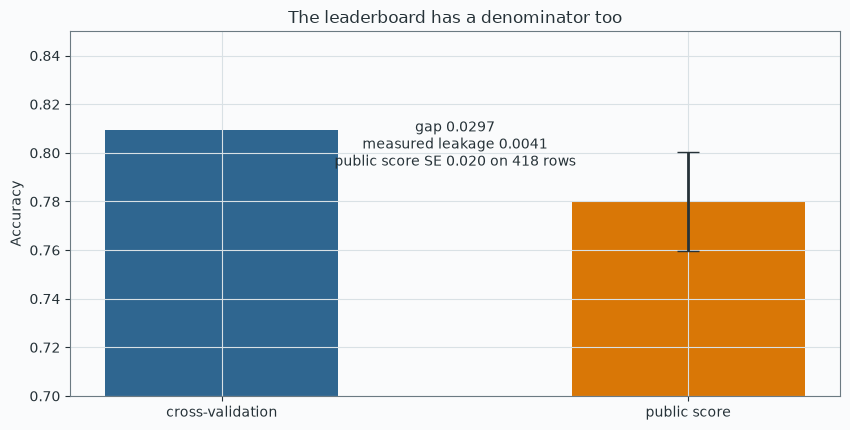

- 交差検証 `0.8096`、公開スコア `0.7799`、差 `0.0297`。  
- 8節で測った家族による上振れは `0.0041` で、差の約 14% にあたる。  
- 公開スコアは`418`行に対する1回の観測で、標準誤差は約 `0.020`。**差は、この幅と同じ桁である。**  
- したがって「公開スコアがCVより低い」こと自体は、過学習の証拠にならない。  
- 分母が`418`だと確かめたのは、得られたスコアがいずれも`418`分の整数になったためである。当初は半分程度と推測していたが、それは確認していない仮定だった。3節で分母を先に固定したのと同じ手続きを、公開スコアに対しては踏んでいなかった。

In [20]:
PUBLIC_SCORE = 0.77990  # 外部観測値。submission 55117112
# 公開スコアは test 418行すべてで計算されている。
# 根拠: このコンペで得た3つのスコアがいずれも418分の整数になる。
#   0.77990 * 418 = 326、0.77751 * 418 = 325、0.74162 * 418 = 310
# 当初は「およそ半分の209行」と仮定していたが、それは確認していない推測だった。
PUBLIC_ROWS = len(test)

cv_mean = depth_by_fold[str(BASELINE_DEPTH)].mean()
leakage_component = judgement["mean"]
gap = cv_mean - PUBLIC_SCORE
public_se = np.sqrt(PUBLIC_SCORE * (1 - PUBLIC_SCORE) / PUBLIC_ROWS)

figure, axis = plt.subplots(figsize=(8.6, 4.4))
axis.bar(["cross-validation", "public score"], [cv_mean, PUBLIC_SCORE],
         color=[COLORS["blue"], COLORS["orange"]], width=0.5)
axis.errorbar([1], [PUBLIC_SCORE], yerr=[[public_se], [public_se]],
              fmt="none", ecolor=COLORS["ink"], elinewidth=2, capsize=8)
axis.annotate(
    f"gap {gap:.4f}\nmeasured leakage {leakage_component:.4f}\n"
    f"public score SE {public_se:.3f} on {PUBLIC_ROWS} rows",
    xy=(0.5, (cv_mean + PUBLIC_SCORE) / 2), ha="center", fontsize=10, color=COLORS["ink"],
)
axis.set_ylim(0.70, 0.85)
axis.set_ylabel("Accuracy")
axis.set_title("The leaderboard has a denominator too")
figure.tight_layout()
plt.show()

display(Markdown(
    f"- 交差検証 `{cv_mean:.4f}`、公開スコア `{PUBLIC_SCORE:.4f}`、差 `{gap:.4f}`。  \n"
    f"- 8節で測った家族による上振れは `{leakage_component:.4f}` で、差の"
    f"約 {100 * leakage_component / gap:.0f}% にあたる。  \n"
    f"- 公開スコアは`{PUBLIC_ROWS}`行に対する1回の観測で、標準誤差は約 `{public_se:.3f}`。"
    "**差は、この幅と同じ桁である。**  \n"
    "- したがって「公開スコアがCVより低い」こと自体は、過学習の証拠にならない。  \n"
    f"- 分母が`{PUBLIC_ROWS}`だと確かめたのは、得られたスコアがいずれも"
    f"`{PUBLIC_ROWS}`分の整数になったためである。当初は半分程度と推測していたが、"
    "それは確認していない仮定だった。3節で分母を先に固定したのと同じ手続きを、"
    "公開スコアに対しては踏んでいなかった。"
))

In [21]:
# 4つの判定結果を標準出力へ出す。実行ログだけで結論を照合できるようにするため。
cabin_verdict = {
    arm_name: int(cabin_results[cabin_results["arm"] == arm_name]["adopt"].sum())
    for arm_name in comparisons
}
print("=== registered outcomes ===")
for arm_name, satisfied in cabin_verdict.items():
    print(
        f"1. Cabin  {arm_name}: {satisfied}/{len(CABIN_DEPTHS)} depths met the rule "
        f"-> {'adopt' if satisfied >= REQUIRED_DEPTHS else 'keep current'}"
    )
print(
    f"2. Leakage inflation: mean {judgement['mean']:+.5f}, "
    f"mean-2SE {judgement['mean_minus_2se']:+.5f} -> "
    f"{'detected' if judgement['mean_minus_2se'] > 0 else 'not detected'}; "
    f"between-arm difference {arm_gap:+.5f}"
)
print(f"3. Age handling selected: {age_selected['arm']}")
print(f"4. Depth selected: {depth_selected['arm']} (leaves {depth_selected['leaves_mean']:.1f})")
print(f"   submission rows: {len(submission)}, predicted survivors: {int(submission[TARGET_COLUMN].sum())}")

=== registered outcomes ===
1. Cabin  drop: 0/6 depths met the rule -> keep current
1. Cabin  deck: 0/6 depths met the rule -> keep current
2. Leakage inflation: mean +0.00413, mean-2SE +0.00067 -> detected; between-arm difference +0.00144
3. Age handling selected: global median
4. Depth selected: 3 (leaves 8.0)
   submission rows: 418, predicted survivors: 150


## 13. 限界 / Limits

- 決定木以外のモデル族と比較していません。結論は決定木の内側に限られます。
- `Age` の比較は深さ3のみで、複数深さに対する頑健性は未検証です。
- `Name` の敬称は年齢と相関しますが、登録した腕に含めていないため比較していません。
- グループの定義は `Ticket` と姓の連結成分のみを試しました。
- 木の `random_state` は42で固定です。同点分割の決着は平均されていません。
- 深さの比較で使ったfoldは学習行が重複するため、独立した100標本として有意差検定には使えません。
- 公開スコアは1回の観測です。この値で設計を変えると、リーダーボードへの適応になります。

### このNotebookの後に起きたこと / What happened after this notebook

この記録の後、5つ目の比較として**モデル族**（決定木・ロジスティック回帰・ランダムフォレスト）を
同じ枠組みで実行しました。ランダムフォレストが決定木を 4.4 SE 上回り、**このNotebookで唯一
採用された変更**になりました。したがって11節の構成は、この記録の時点のものです。

その提出結果も併せて記録します。CVで `+0.0071` 上回った構成が、公開スコアでは `-0.0024`
でした。両者の差は公開スコアの標準誤差の内側で、**1回の観測では判定できない大きさ**です。
CVと公開スコアのどちらが正しいかを、この1提出から決めることはできません。

## 14. AI支援の範囲 / AI assistance

コードの雛形、実行検査、Notebookの構成整理にはAIを利用しました。
比較する腕、判定式、閾値、seed数、深さの候補範囲は、実行前に人が決めています。
観察の解釈と、次に何を確かめるかも人が書いています。

AIが判定を選んだ箇所はありません。判定ルールが結論を決めていた回があること自体を、
結果として残しています。

> **English:** AI assisted with scaffolding, execution checks and structure. The arms, the
> decision rules, the thresholds and the candidate ranges were fixed by the author before each
> run. Where a rule, rather than the data, decided the outcome, that is recorded as a result.